In [3]:
import matplotlib.pyplot as plt # type:ignore
import seaborn as sns # type:ignore
import pandas as pd # type:ignore
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

In [5]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [6]:
# Convert data types
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['SeniorCitizen'] = df['SeniorCitizen'].astype('str')
df['customerID'] = df['customerID'].astype('object')

print("Data types after conversion:")
print(df[['TotalCharges', 'SeniorCitizen', 'customerID']].dtypes)

Data types after conversion:
TotalCharges     float64
SeniorCitizen        str
customerID        object
dtype: object


In [7]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df.dtypes

customerID           object
gender                  str
SeniorCitizen           str
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [9]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6530
Churn                  2
dtype: int64

In [10]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [11]:
# Print unique values for categorical columns
categorical_cols = df.select_dtypes(include=['str']).columns

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].unique())


gender:
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

SeniorCitizen:
<StringArray>
['0', '1']
Length: 2, dtype: str

Partner:
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

PhoneService:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines:
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

InternetService:
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

OnlineSecurity:
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

OnlineBackup:
<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

DeviceProtection:
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

TechSupport:
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

StreamingTV:
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

StreamingMovies:
<StringArray>
['No', 'Yes', 'No internet service']
Len

/tmp/ipykernel_277949/2926524163.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=['object']).columns.difference(exclude_cols)


Categorical Features: ['Contract', 'Dependents', 'DeviceProtection', 'InternetService', 'MultipleLines', 'OnlineBackup', 'OnlineSecurity', 'PaperlessBilling', 'Partner', 'PaymentMethod', 'PhoneService', 'SeniorCitizen', 'StreamingMovies', 'StreamingTV', 'TechSupport', 'gender']
Numerical Features: ['MonthlyCharges', 'TotalCharges', 'tenure']


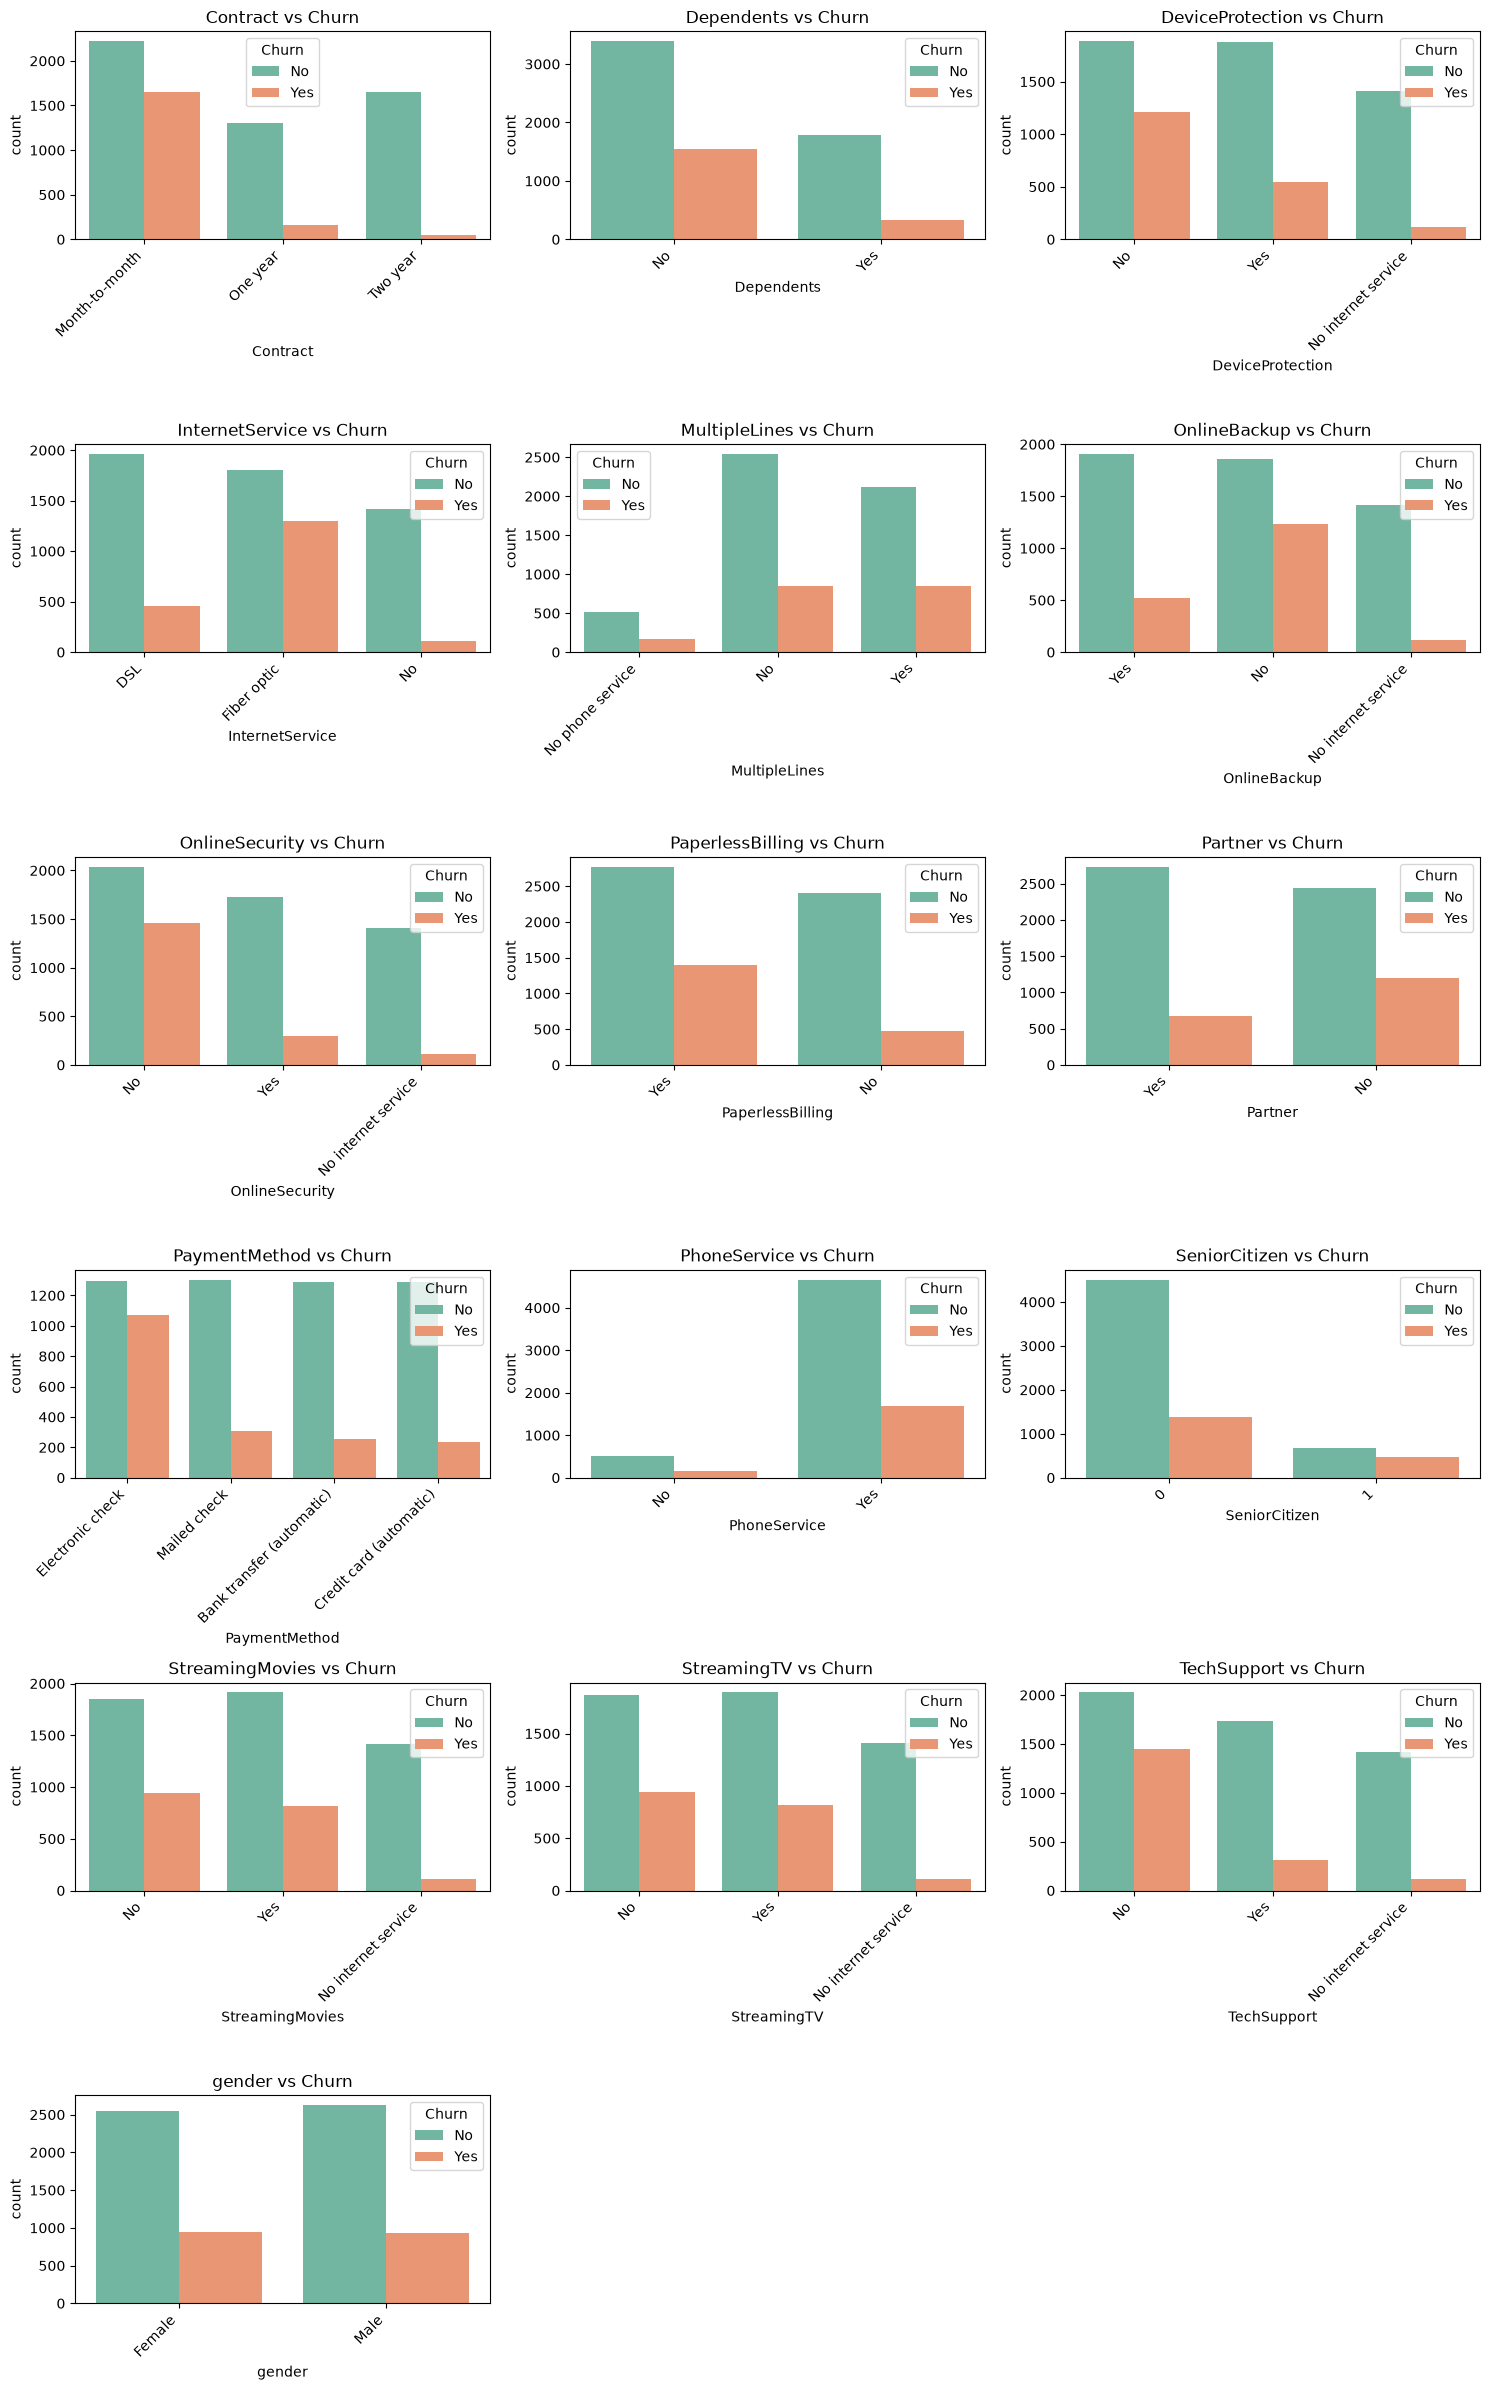

/tmp/ipykernel_277949/2926524163.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=col, palette='Set2')
/tmp/ipykernel_277949/2926524163.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=col, palette='Set2')
/tmp/ipykernel_277949/2926524163.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=col, palette='Set2')


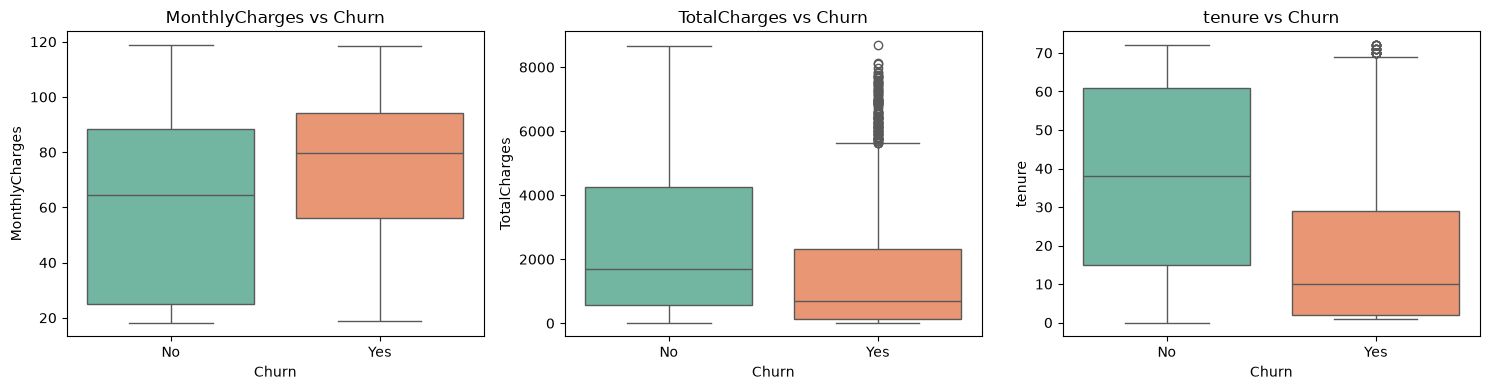

In [12]:
# Identify target column
target_col = 'Churn'

# Get categorical and numerical columns (excluding target and non-predictive columns)
exclude_cols = [target_col, 'customerID']
categorical_features = df.select_dtypes(include=['object']).columns.difference(exclude_cols)
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.difference(exclude_cols)

print("Categorical Features:", categorical_features.tolist())
print("Numerical Features:", numerical_features.tolist())

# Visualize categorical columns vs target (Churn)
num_cat = len(categorical_features)
cols = 3
rows = (num_cat + cols - 1) // cols  # Calculate rows needed dynamically
plt.figure(figsize=(15, 4*rows))
for idx, col in enumerate(categorical_features, 1):
    plt.subplot(rows, cols, idx)
    sns.countplot(data=df, x=col, hue=target_col, palette='Set2')
    plt.title(f'{col} vs {target_col}')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Visualize numerical columns vs target (Churn)
num_num = len(numerical_features)
cols = 3
rows = (num_num + cols - 1) // cols  # Calculate rows needed dynamically
plt.figure(figsize=(15, 4*rows))
for idx, col in enumerate(numerical_features, 1):
    plt.subplot(rows, cols, idx)
    sns.boxplot(data=df, x=target_col, y=col, palette='Set2')
    plt.title(f'{col} vs {target_col}')
plt.tight_layout()
plt.show()